impoting libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

loading dataset


In [4]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())
df.describe()

Dataset Shape: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Defining features and target

In [7]:
X = df.drop('Price', axis=1)

y = df['Price']

splitting dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


featuring scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


regression model

In [10]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

# Predictions
linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression Training Completed")

Linear Regression Training Completed


evaluating model

In [11]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2 Score:", linear_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2 Score: 0.575787706032451


Ridge Regression

In [12]:
ridge_model = Ridge()

ridge_model.fit(X_train_scaled, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test_scaled)

print("Ridge Regression Training Completed")

Ridge Regression Training Completed


In [13]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2 Score:", ridge_r2)

Ridge Regression RMSE: 0.7455567442814779
Ridge Regression R2 Score: 0.5758157428913684


Decision Tree

In [14]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

# Predictions
tree_pred = tree_model.predict(X_test)

print("Decision Tree Training Completed")

Decision Tree Training Completed


In [15]:
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2 Score:", tree_r2)

Decision Tree RMSE: 0.7037294974840077
Decision Tree R2 Score: 0.622075845135081


comaring all models

In [16]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Decision Tree'
    ],

    'RMSE': [
        linear_rmse,
        ridge_rmse,
        tree_rmse
    ],

    'R2 Score': [
        linear_r2,
        ridge_r2,
        tree_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.703729,0.622076


visualization

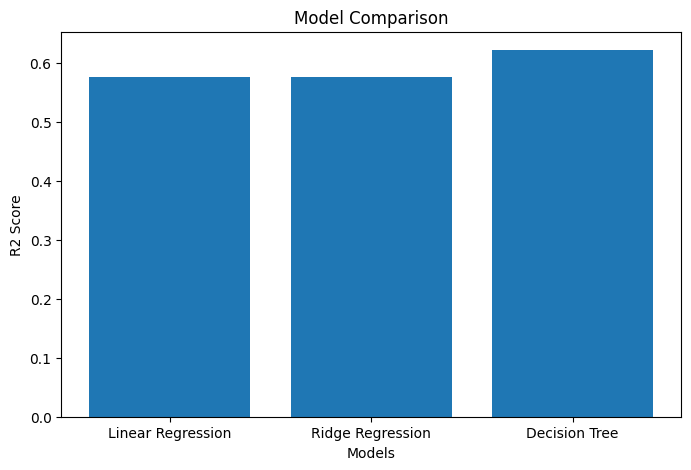

In [17]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.show()

Actual vs Predicted Plot

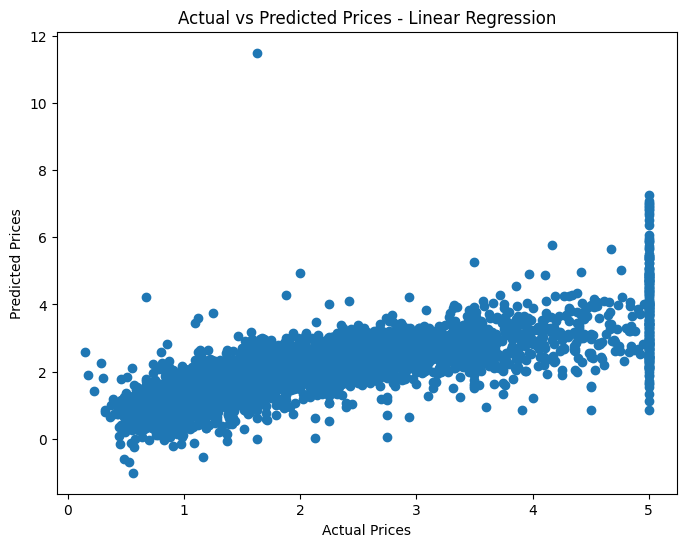

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices - Linear Regression")

plt.show()